## Import Libraries

In [ ]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate,
    Multiply,
    Lambda
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
MAX_WORDS = 10000
MAX_LEN = 100

EMBEDDING_DIM = 64
LSTM_UNITS = 64

BATCH_SIZE = 64
EPOCHS = 5

print("Parameters Initialized")

Parameters Initialized


## Load Dataset

In [ ]:
# Load JSONL dataset

DATA_CANDIDATES = [
    Path("/content/train.jsonl"),
    Path("/content/drive/MyDrive/train.jsonl"),
    Path("train.jsonl"),
    Path(r"C:\Users\akank\Downloads\train.jsonl")
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    from google.colab import files

    uploaded = files.upload()
    DATA_PATH = Path(next(iter(uploaded.keys())))

print("Using Dataset:", DATA_PATH)

def read_jsonl(path):
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records

records = read_jsonl(DATA_PATH)

print("Total Records :", len(records))
print("Columns :", list(records[0].keys()))

df = pd.DataFrame(records)

print(df.shape)

df.head()

df.info()

df.isnull().sum()


Saving train.jsonl to train.jsonl
Using Dataset: train.jsonl
Total Records : 50000
Columns : ['Job-Description', 'Resume-matched', 'Resume-unmatched', 'Skills', 'Experiences', 'Experiences-years', 'Filtered-information']
(50000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Job-Description       50000 non-null  object
 1   Resume-matched        50000 non-null  object
 2   Resume-unmatched      50000 non-null  object
 3   Skills                50000 non-null  object
 4   Experiences           50000 non-null  object
 5   Experiences-years     50000 non-null  object
 6   Filtered-information  50000 non-null  object
dtypes: object(7)
memory usage: 2.7+ MB


,0
Job-Description,0
Resume-matched,0
Resume-unmatched,0
Skills,0
Experiences,0
Experiences-years,0
Filtered-information,0


In [ ]:
# Positive Pair (Matched Resume + JD)
positive = pd.DataFrame({
    "resume": df["Resume-matched"],
    "jd": df["Job-Description"],
    "label": 2          # Strong Match
})

# Negative Pair (Unmatched Resume + JD)
negative = pd.DataFrame({
    "resume": df["Resume-unmatched"],
    "jd": df["Job-Description"],
    "label": 0          # Weak Match
})

# Combine
data = pd.concat([positive, negative], ignore_index=True)

data.head()

,resume,jd,label
0,\n\n## Personal Information\nName: Konstantina...,\n\n## Job Title\nOracle SCM Developer\n\n## J...,2
1,\n\n## Personal Information\nName: Yelena Belo...,"\n\n## Job Title\nElectrical, Electronic, and ...",2
2,\n\n## Personal Information\nName: Matthew Ste...,\n\n## Job Title\nUI - Sr. Java Tech Lead (Por...,2
3,\n\n## Personal Information\nName: Haruna Yaku...,\n\n## Job title\nTechnical Architect- JAVA\n\...,2
4,\n\n## Personal Information\nName: Finley Murr...,\n\n## Job title\nFishing and Hunting Worker\n...,2


In [ ]:
medium = positive.copy()

medium["resume"] = medium["resume"].sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

medium["label"] = 1

data = pd.concat([data, medium], ignore_index=True)

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(data["label"].value_counts())

label
0    50000
2    50000
1    50000
Name: count, dtype: int64


In [ ]:
#Text cleaning
def clean(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    return text

data["resume"] = data["resume"].apply(clean)
data["jd"] = data["jd"].apply(clean)

data.head()

,resume,jd,label
0,personal information name siti gomez e...,job title sr project manager w ui focus ...,0
1,personal information name vusala evans e...,job title principal network architect ...,2
2,personal information name aysa flowers e...,job title supervisors of farming fishing...,1
3,personal information name nikodem ...,job title licensed practical and licensed ...,1
4,personal information name shristi cha...,job title networking systems security eng...,1


## Train/Test Split

In [ ]:
X_resume = data["resume"]
X_jd = data["jd"]
y = data["label"]

X_resume_train, X_resume_test, \
X_jd_train, X_jd_test, \
y_train, y_test = train_test_split(
    X_resume,
    X_jd,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_resume_train))
print("Testing Samples  :", len(X_resume_test))

Training Samples : 120000
Testing Samples  : 30000


## Tokenizer + Padding

In [ ]:
# Create Tokenizer
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<UNK>"
)

tokenizer.fit_on_texts(
    list(data["resume"]) +
    list(data["jd"])
)

print("Vocabulary Size :", len(tokenizer.word_index))

Vocabulary Size : 112497


In [ ]:
# Resume sequences
X_resume_train = tokenizer.texts_to_sequences(X_resume_train)
X_resume_test = tokenizer.texts_to_sequences(X_resume_test)

# JD sequences
X_jd_train = tokenizer.texts_to_sequences(X_jd_train)
X_jd_test = tokenizer.texts_to_sequences(X_jd_test)

In [ ]:
#Padding
X_resume_train = pad_sequences(
    X_resume_train,
    maxlen=MAX_LEN,
    padding="post"
)

X_resume_test = pad_sequences(
    X_resume_test,
    maxlen=MAX_LEN,
    padding="post"
)

X_jd_train = pad_sequences(
    X_jd_train,
    maxlen=MAX_LEN,
    padding="post"
)

X_jd_test = pad_sequences(
    X_jd_test,
    maxlen=MAX_LEN,
    padding="post"
)

In [ ]:
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Resume Shape :", X_resume_train.shape)
print("JD Shape     :", X_jd_train.shape)
print("Labels Shape :", y_train.shape)

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary :", VOCAB_SIZE)
print("Max Length :", MAX_LEN)

Resume Shape : (120000, 100)
JD Shape     : (120000, 100)
Labels Shape : (120000,)
Vocabulary : 10000
Max Length : 100


## Siamese BiLSTM Model

In [ ]:
# Resume Input
resume_input = Input(shape=(MAX_LEN,), name="Resume_Input")

# Job Description Input
jd_input = Input(shape=(MAX_LEN,), name="JD_Input")

# Shared Layers
embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)

bilstm = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True)
)

pool = GlobalMaxPooling1D()

# Encoder Function
def encoder(x):
    x = embedding(x)
    x = bilstm(x)
    x = pool(x)
    return x

resume_vector = encoder(resume_input)
jd_vector = encoder(jd_input)

# |u-v|
difference = Lambda(
    lambda x: tf.abs(x[0] - x[1])
)([resume_vector, jd_vector])

# u*v
multiply = Multiply()([
    resume_vector,
    jd_vector
])

merged = Concatenate()([
    resume_vector,
    jd_vector,
    difference,
    multiply
])

x = Dense(128, activation="relu")(merged)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)

output = Dense(
    3,
    activation="softmax"
)(x)

model = Model(
    inputs=[resume_input, jd_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Resume_Input        │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ JD_Input            │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │    640,000 │ Resume_Input[0][… │
│ (Embedding)         │                   │            │ JD_Input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 128)  │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ lambda[0][0],     │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 780,163 (2.98 MB)

 Trainable params: 780,163 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    [X_resume_train, X_jd_train],
    y_train,
    validation_data=([X_resume_test, X_jd_test], y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

model.save("resume_jd_match_model.keras")

print("Model Saved Successfully!")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 502s 265ms/step - accuracy: 0.7417 - loss: 0.5287 - val_accuracy: 0.8127 - val_loss: 0.3891
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 506s 267ms/step - accuracy: 0.8467 - loss: 0.3348 - val_accuracy: 0.8350 - val_loss: 0.3455
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 497s 265ms/step - accuracy: 0.8794 - loss: 0.2727 - val_accuracy: 0.8470 - val_loss: 0.3338
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 500s 266ms/step - accuracy: 0.9028 - loss: 0.2283 - val_accuracy: 0.8596 - val_loss: 0.3161
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 496s 265ms/step - accuracy: 0.9221 - loss: 0.1895 - val_accuracy: 0.8579 - val_loss: 0.3431
Model Saved Successfully!


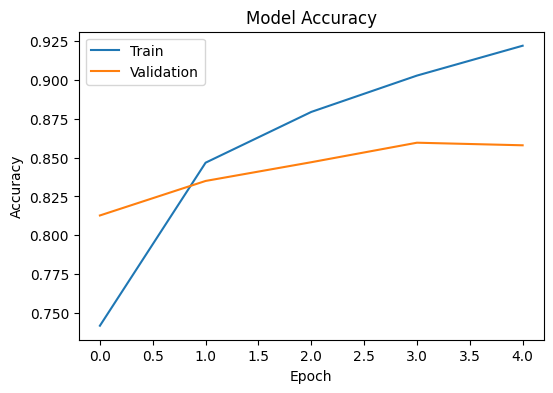

In [ ]:
#Plot Accuracy
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

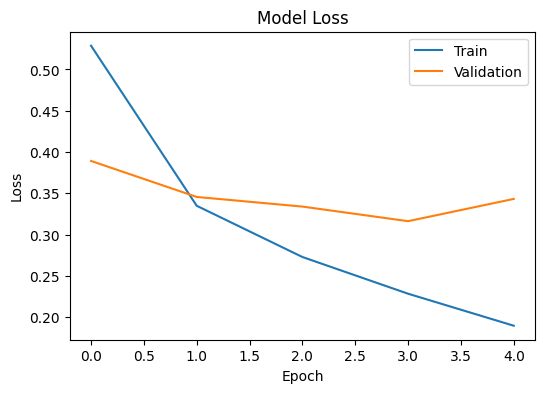

In [ ]:
#Plot Loss
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
print("Training Accuracy :",
      round(history.history["accuracy"][-1],4))

print("Validation Accuracy :",
      round(history.history["val_accuracy"][-1],4))

Training Accuracy : 0.9221
Validation Accuracy : 0.8579


## Evaluate

Test Accuracy : 0.8596
Test Loss     : 0.3161
              precision    recall  f1-score   support

        Weak       0.84      0.73      0.78     10000
      Medium       0.98      0.99      0.98     10000
      Strong       0.77      0.86      0.81     10000

    accuracy                           0.86     30000
   macro avg       0.86      0.86      0.86     30000
weighted avg       0.86      0.86      0.86     30000



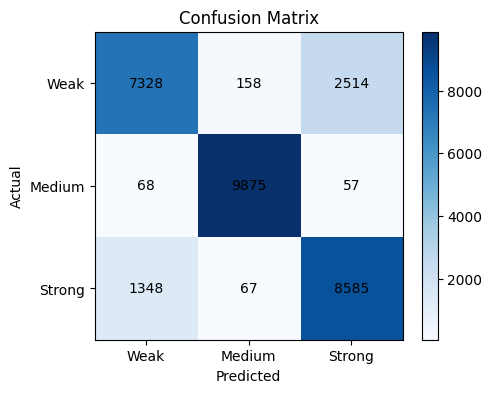

In [ ]:
# Evaluate model
loss, accuracy = model.evaluate(
    [X_resume_test, X_jd_test],
    y_test,
    verbose=0
)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Loss     : {loss:.4f}")

# Predict probabilities
y_pred = model.predict(
    [X_resume_test, X_jd_test],
    verbose=0
)

# Convert to class labels
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Weak","Medium","Strong"]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")

plt.xticks([0,1,2],["Weak","Medium","Strong"])
plt.yticks([0,1,2],["Weak","Medium","Strong"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j],
                 ha="center", va="center")

plt.colorbar()
plt.show()

labels = ["Weak", "Medium", "Strong"]


## Prediction

In [ ]:
COMMON_SKILLS = [
    "python", "sql", "java", "javascript", "html", "css", "react", "node", "fastapi",
    "docker", "kubernetes", "aws", "azure", "gcp", "tensorflow", "keras", "pytorch",
    "machine learning", "deep learning", "nlp", "rag", "vector database", "mongodb",
    "postgresql", "spark", "etl", "tableau", "power bi", "excel", "linux", "git"
]

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def predict_match(resume_text, jd_text):

    resume = clean_text(resume_text)
    jd = clean_text(jd_text)

    resume = tokenizer.texts_to_sequences([resume])
    jd = tokenizer.texts_to_sequences([jd])

    resume = pad_sequences(resume, maxlen=MAX_LEN, padding="post")
    jd = pad_sequences(jd, maxlen=MAX_LEN, padding="post")

    pred = model.predict([resume, jd], verbose=0)

    labels = ["Weak Match", "Medium Match", "Strong Match"]

    index = np.argmax(pred)

    return labels[index], pred[0][index]

def skill_match(resume_text, jd_text):

    resume = clean_text(resume_text)
    jd = clean_text(jd_text)

    matched = []
    missing = []

    for skill in COMMON_SKILLS:

        resume_has = skill in resume
        jd_has = skill in jd

        if resume_has and jd_has:
            matched.append(skill)

        elif jd_has and not resume_has:
            missing.append(skill)

    return matched, missing

resume = input("Enter Resume Text:\n")

print()

job = input("Enter Job Description:\n")

match, confidence = predict_match(resume, job)

matched, missing = skill_match(resume, job)

print("="*50)
print("Resume-JD Match Result")
print("="*50)

print("\nPrediction :", match)
print(f"Confidence : {confidence*100:.2f}%")

print("\nMatched Skills")
print("----------------")

if matched:
    for skill in matched:
        print("✓", skill.title())
else:
    print("No matched skills found.")

print("\nMissing Skills")
print("----------------")

if missing:
    for skill in missing:
        print("✗", skill.title())
else:
    print("No missing skills.")

print("\nRecommendation")
print("----------------")

if match == "Strong Match":
    print("Excellent! Your resume is a strong match for this job.")

elif match == "Medium Match":
    print("Good match. Consider adding these skills:")
    if missing:
        print(", ".join(skill.title() for skill in missing))

else:
    print("Weak match. Improve your resume by adding:")
    if missing:
        print(", ".join(skill.title() for skill in missing))

Enter Resume Text:
Python, SQL, TensorFlow, Docker

Enter Job Description:
Looking for Python Developer with SQL, TensorFlow, Docker, AWS and Kubernetes.
Resume-JD Match Result

Prediction : Weak Match
Confidence : 96.87%

Matched Skills
----------------
✓ Python
✓ Sql
✓ Docker
✓ Tensorflow

Missing Skills
----------------
✗ Kubernetes
✗ Aws

Recommendation
----------------
Weak match. Improve your resume by adding:
Kubernetes, Aws
